In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import pandas as pd

# Load the dataset
file_path = r"C:\Users\mtk17\My Drive\PhD\Conference Papers\SoC Prediction Matlab\Data\Plant_1_Generation_Data.csv"
data = pd.read_csv(file_path)


# Exclude the SOCcars columns from the input features
X = data.drop(columns=['DATE_TIME','PLANT_ID','SOURCE_KEY','TOTAL_YIELD'])

# Assume 'LOAD' is the target column, but you can change this to another column if required
y = data['TOTAL_YIELD']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Scale the target variable (if it's not categorical)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Define the ANN model for regression
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=32, verbose=1)

# Predict and evaluate the model
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Inverse transform predictions
y_true = y_test.values.reshape(-1, 1)  # y_test is already the true values

# Calculate the metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Epoch 1/100
1720/1720 [==============================] - 2s 778us/step - loss: 1.0023
Epoch 2/100
1720/1720 [==============================] - 1s 747us/step - loss: 0.9998
Epoch 3/100
1720/1720 [==============================] - 1s 740us/step - loss: 0.9990
Epoch 4/100
1720/1720 [==============================] - 1s 760us/step - loss: 0.9982
Epoch 5/100
1720/1720 [==============================] - 1s 753us/step - loss: 0.9975
Epoch 6/100
1720/1720 [==============================] - 1s 740us/step - loss: 0.9970
Epoch 7/100
1720/1720 [==============================] - 1s 790us/step - loss: 0.9960
Epoch 8/100
1720/1720 [==============================] - 1s 766us/step - loss: 0.9958
Epoch 9/100
1720/1720 [==============================] - 1s 750us/step - loss: 0.9957
Epoch 10/100
1720/1720 [==============================] - 1s 750us/step - loss: 0.9956
Epoch 11/100
1720/1720 [==============================] - 1s 747us/step - loss: 0.9952
Epoch 12/100
1720/1720 [============================

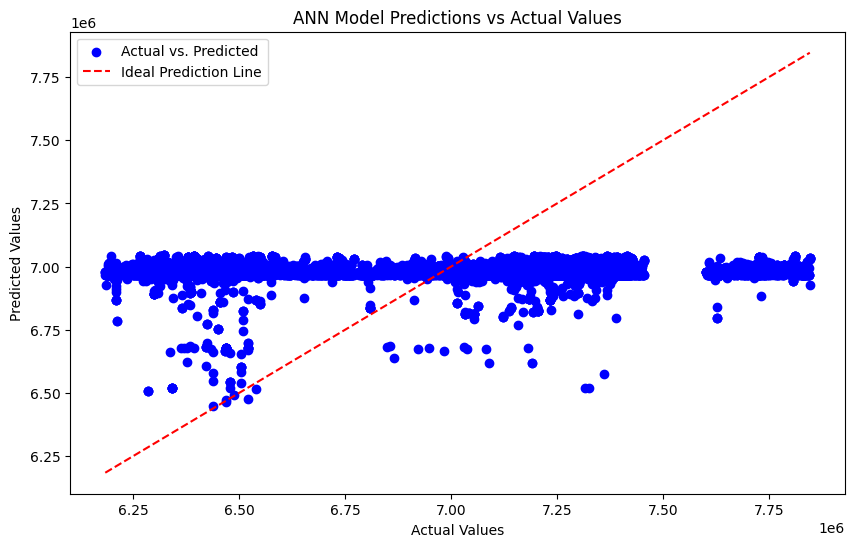

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Prediction Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('ANN Model Predictions vs Actual Values')
plt.legend()
plt.show()